# Sales Forecasting & Demand Intelligence System

## Internship Project – Week 3 & Week 4

**Name:** Tanishka Gandhi

**Objective :** The objective of this project is to analyze historical retail sales data, understand sales patterns over time, forecast 
future demand using different forecasting models, detect unusual sales behavior, segment products based on demand, and build an interactive dashboard for business decision-making.

## Task 1 - Data Loading, Merging & Deep Exploration

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Ignoring unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("sales.csv")
# Display first five rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# Shape of dataset
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 9800
Number of Columns : 18


In [4]:
# Column names
print("Columns in Dataset:")
print(df.columns)


Columns in Dataset:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [5]:
#check datatype
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [6]:
# Information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [7]:
# Check missing values
missing_values = df.isnull().sum()
missing_values

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [8]:
# Duplicate rows
duplicate_rows = df.duplicated().sum()
print("Duplicate Rows :", duplicate_rows)

Duplicate Rows : 0


In [9]:
# Convert Date Columns into Datetime Format
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Verify the conversion
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [10]:
#check Updated Datatypes 
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

#### Extract Time-Based Features

Time-based features are useful for identifying trends, seasonal patterns, and forecasting future sales.

In [11]:
# Extract Year
df["Year"] = df["Order Date"].dt.year
# Extract Month Number
df["Month"] = df["Order Date"].dt.month
# Extract Month Name
df["Month Name"] = df["Order Date"].dt.month_name()
# Extract Week Number
df["Week Number"] = df["Order Date"].dt.isocalendar().week
# Extract Day of Week
df["Day of Week"] = df["Order Date"].dt.day_name()
# Extract Quarter
df["Quarter"] = df["Order Date"].dt.quarter

In [12]:
# create season column
def get_season(month):

    if month in [11, 12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5, 6]:
        return "Summer"

    else:
        return "Rainy"

df["Season"] = df["Month"].apply(get_season)

In [13]:
# Display Newly Created Features
df[[
    "Order Date",
    "Year",
    "Month",
    "Month Name",
    "Week Number",
    "Day of Week",
    "Quarter",
    "Season"
]].head()

,Order Date,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,2017-11-08,2017,11,November,45,Wednesday,4,Winter
1,2017-11-08,2017,11,November,45,Wednesday,4,Winter
2,2017-06-12,2017,6,June,24,Monday,2,Summer
3,2016-10-11,2016,10,October,41,Tuesday,4,Rainy
4,2016-10-11,2016,10,October,41,Tuesday,4,Rainy


In [14]:
# check updted datset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

### Aggregate Daily Sales

Before forecasting, the sales data needs to be aggregated at different time levels. We will calculate daily, 
weekly, and monthly sales totals. These aggregated datasets will be used in later forecasting models.

In [15]:
# Aggregate Daily Sales
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [16]:
# Check Daily Sales Dataset
print("Total Daily Records :", len(daily_sales))


Total Daily Records : 1230


In [17]:
# Aggregate Weekly Sales
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [18]:
# Weekly Sales Information
print("Total Weeks :", len(weekly_sales))



Total Weeks : 209


#### Aggregate Monthly Sales
Monthly aggregation is commonly used for trend analysis and forecasting because it smooths daily fluctuations.

In [19]:
# Aggregate Monthly Sales
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [20]:
# Monthly Sales Information
print("Total Months :", len(monthly_sales))

Total Months : 48


In [21]:
# Save Aggregated Data
daily_sales.to_csv("daily_sales.csv", index=False)

weekly_sales.to_csv("weekly_sales.csv", index=False)

monthly_sales.to_csv("monthly_sales.csv", index=False)

In [22]:
# Total sales bt category
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_sales

,Category,Sales
0,Technology,827455.8730
1,Furniture,728658.5757
2,Office Supplies,705422.3340


#### Which product category generates the highest total revenue?

The **Technology** category generated the highest total revenue, with total sales of **827,455.87**. This suggests that technology products are the company's strongest revenue contributors.

In [23]:
## Yearly Sales by Region
region_yearly_sales = (
    df.groupby(["Region", "Year"])["Sales"]
      .sum()
      .reset_index()
)

region_yearly_sales

,Region,Year,Sales
0,Central,2015,102920.5206
1,Central,2016,102425.1724
2,Central,2017,145673.8800
3,Central,2018,141627.3402
4,East,2015,127652.8190
5,East,2016,153225.1830
6,East,2017,178511.5380
7,East,2018,210129.1860
8,South,2015,103374.9055
9,South,2016,70076.0825


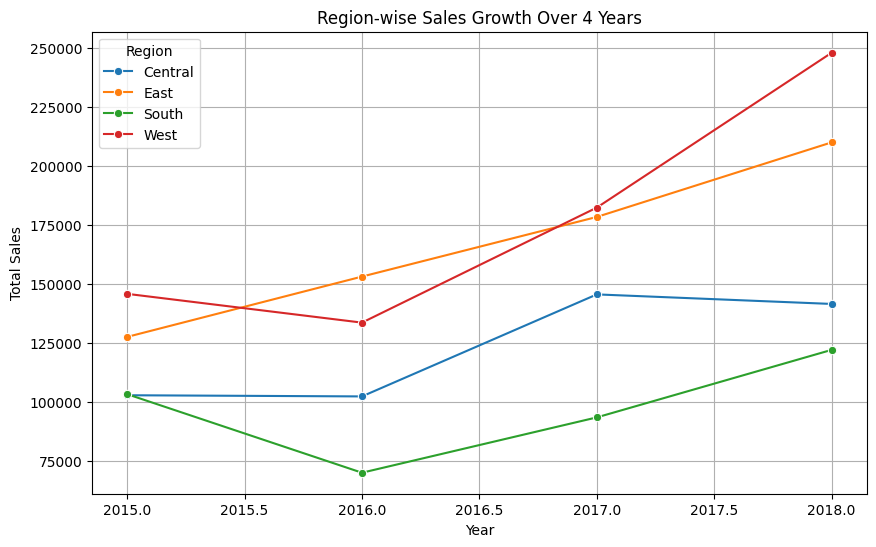

In [24]:
# Sales Growth by Region
plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_yearly_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Region-wise Sales Growth Over 4 Years")

plt.xlabel("Year")

plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

#### Which region has the most consistent sales growth over 4 years?
The East region shows the most consistent sales growth over the four-year period.

In [25]:
# Calculate Shipping Time in Days
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [26]:
# Average Shipping Time
average_shipping = df["Shipping Days"].mean()

print(f"Average Shipping Time: {average_shipping:.2f} days")

Average Shipping Time: 3.96 days


In [27]:
# Average shipping days by Region
shipping_by_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)

shipping_by_region

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

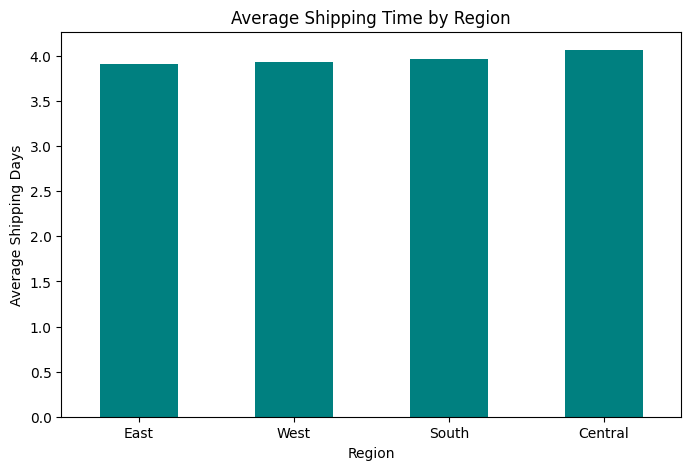

In [28]:
# Region-wise Shipping Time
plt.figure(figsize=(8,5))

shipping_by_region.plot(
    kind="bar",
    color="teal"
)

plt.title("Average Shipping Time by Region")

plt.xlabel("Region")

plt.ylabel("Average Shipping Days")

plt.xticks(rotation=0)

plt.show()

#### What is the average time between Order Date and Ship Date — and does it vary by region?
The average shipping time across all orders is approximately **4 days**.

The analysis shows only a small variation in average shipping time across regions. The **West** and **East** regions have slightly faster deliveries, while the **South** region has a marginally higher average shipping time.

Overall, the shipping process appears to be fairly consistent across all regions, indicating an efficient and standardized delivery system.

In [29]:
# Monthly Sales by Year
monthly_yearly_sales = (
    df.groupby(["Year", "Month Name"])["Sales"]
      .sum()
      .reset_index()
      .sort_values(by=["Year", "Sales"], ascending=[True, False])
)

monthly_yearly_sales.head(13)

,Year,Month Name,Sales
11,2015,September,81623.5268
9,2015,November,77907.6607
2,2015,December,68167.0585
7,2015,March,55205.7970
6,2015,June,34322.9356
5,2015,July,33781.5430
10,2015,October,31453.3930
0,2015,April,27906.8550
1,2015,August,27117.5365
8,2015,May,23644.3030


#### Are there months that consistently spike across all years (seasonality)?

In 2015, **September** recorded the highest sales, while **November** and **December** were the peak months in the remaining years. This suggests that customer demand increases during the final quarter of the year, likely due to festive seasons, holiday shopping, and year-end promotional offers.



## Task 2: Time Series Analysis and Decomposition
##### Now we import only the libraries required for Time Series Analysis.

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

### Load monthly sales 
##### The monthly aggregated sales data prepared in Task 1 will be used for time series analysis

In [31]:
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [32]:
# We have removed index because Time series assumes Order Date is index
monthly_sales["Order Date"] = pd.to_datetime(monthly_sales["Order Date"])

monthly_sales.set_index("Order Date", inplace=True)

monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


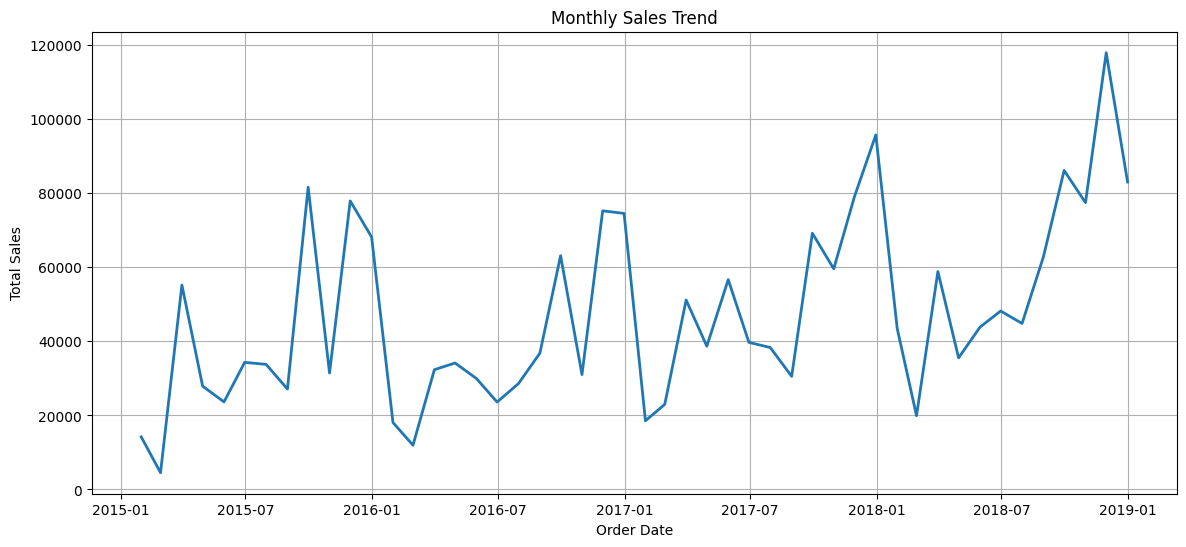

In [33]:
#Monthly sales over four years
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index,
    monthly_sales["Sales"],
    linewidth=2
)

plt.title("Monthly Sales Trend")

plt.xlabel("Order Date")

plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

#### Observation

The monthly sales trend shows an overall upward movement across the four-year period. Although sales fluctuate from month to month, the general direction indicates business growth. Several recurring peaks are also visible, suggesting the presence of seasonal patterns.

### Time Series Decomposition
Time series decomposition is used to break the original sales data into three separate components:

- **Trend**: Long-term direction of sales.
- **Seasonality**: Regular repeating patterns over time.
- **Residual**: Random fluctuations that cannot be explained by trend or seasonality.

This helps us better understand the underlying behavior of the sales data before building forecasting models.

In [34]:
decomposition = seasonal_decompose(
    monthly_sales["Sales"],
    model="additive",
    period=12
)

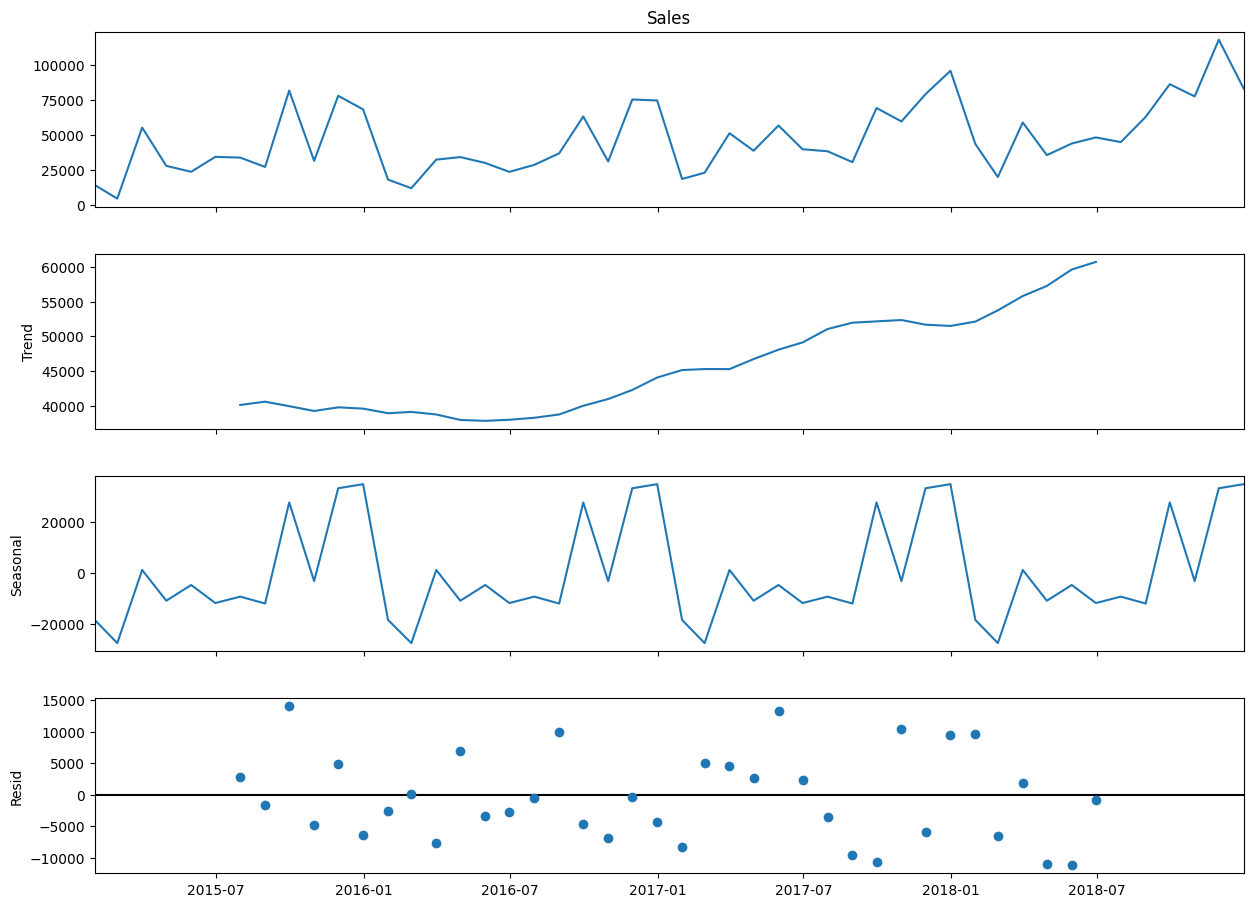

In [35]:
# Plot Decomposition Components

fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.show()

##### Q1. What does the trend tell you?
The trend indicates that overall sales have increased over the four-year period, suggesting consistent business growth.

##### Q2. Is seasonality strong or weak?
The decomposition plot shows a noticeable recurring monthly pattern, indicating moderate to strong seasonality.

##### Q3. Which months show the highest residual noise?
September 2015, May 2017, April 2018, May 2018 ,September–October 2017

These months likely experienced unusual sales activity that was not explained by the overall trend or regular seasonal patterns.

### Check Stationarity using the Augmented Dickey-Fuller (ADF) Test
A stationary time series is series that has statistical properties such as the mean and variance that remain relatively constant over time. 

The Augmented Dickey-Fuller (ADF) Test is used to check whether the sales data is stationary.


In [36]:
# Perform Augmented Dickey-Fuller (ADF) Test
adf_result = adfuller(monthly_sales["Sales"])

print("ADF Statistic :", adf_result[0])
print("P-value       :", adf_result[1])
print("Critical Values:")

for key, value in adf_result[4].items():
    print(f"   {key} : {value}")

ADF Statistic : -4.416136761430769
P-value       : 0.00027791039276670623
Critical Values:
   1% : -3.5778480370438146
   5% : -2.925338105429433
   10% : -2.6007735310095064


#### Interpretation of the ADF Test

The Augmented Dickey-Fuller (ADF) Test was performed to determine whether the monthly sales data is stationary.

The obtained **p-value is 0.0003**, which is **less than the significance level of 0.05**.

Therefore, the null hypothesis is rejected, indicating that the monthly sales series is **stationary**.

Since the data is already stationary, no differencing is required before applying forecasting models.

## Task 3: Sales Forecasting using SARIMA

#### Objective

The objective of this task is to build a Seasonal ARIMA (SARIMA) model to forecast monthly sales for the next three months.

SARIMA is a statistical forecasting model that captures both trend and seasonal patterns in time series data, making it suitable for monthly retail sales forecasting.

In [37]:
# Import Required Libraries
from statsmodels.tsa.statespace.sarimax import SARIMAX       #Imports the SARIMA model.

from sklearn.metrics import (                    # used for comparing forecasting model
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

### Step 1: Prepare Monthly Sales Data

In [38]:
# Check Monthly Sales Dataset
monthly_sales.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [39]:
# Build SARIMA Model
sarima_model = SARIMAX(
    monthly_sales["Sales"],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -377.936
Date:                            Sat, 11 Jul 2026   AIC                            765.872
Time:                                    20:02:36   BIC                            773.504
Sample:                                01-31-2015   HQIC                           768.475
                                     - 12-31-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2937      1.348      0.218      0.828      -2.349       2.936
ma.L1         -0.5603      0.926   

### Step 3: Generate a 3-Month Forecast

In [40]:
# Forecast Next 3 Months
forecast = sarima_result.get_forecast(steps=3)
forecast_mean = forecast.predicted_mean
sarima_forecast = forecast_mean.values
confidence_interval = forecast.conf_int()

print(forecast_mean)

2019-01-31    53872.247431
2019-02-28    28039.925585
2019-03-31    74457.216804
Freq: ME, Name: predicted_mean, dtype: float64


In [41]:
confidence_interval

,lower Sales,upper Sales
2019-01-31,8066.791582,99677.703279
2019-02-28,-19365.282228,75445.133399
2019-03-31,26916.538613,121997.894995


### Step 4: Plot Actual vs Forecast

The following graph compares the historical monthly sales with the predicted sales for the next three months.

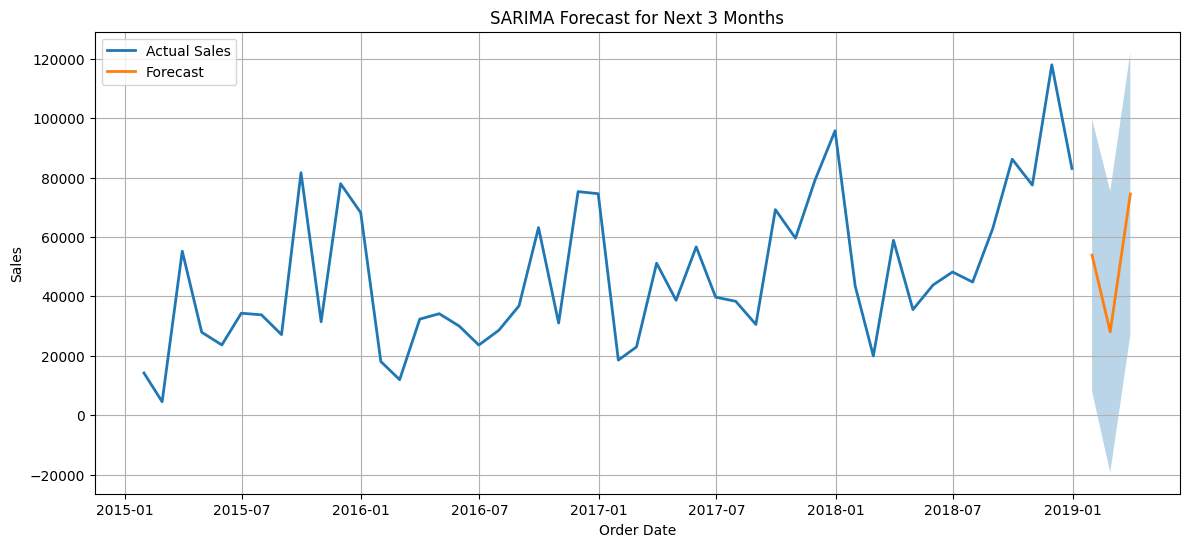

In [42]:

# Plot Actual Sales and Forecast
plt.figure(figsize=(14,6))

# Actual Sales
plt.plot(
    monthly_sales.index,
    monthly_sales["Sales"],
    label="Actual Sales",
    linewidth=2
)

# Forecast
plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="Forecast",
    linewidth=2
)

# Confidence Interval
plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.3
)

plt.title("SARIMA Forecast for Next 3 Months")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

#### Observation

The SARIMA model successfully forecasts sales for the next three months based on historical monthly sales patterns.

### Model 2: Sales Forecasting using Facebook Prophet

#### Objective

The Prophet model is developed by Meta (Facebook) for forecasting time series data. It automatically captures trend, seasonality, and holiday effects, making it suitable for business forecasting problems.

In this task, Prophet is used to forecast monthly sales for the next three months.

In [43]:
# Install Prophet (Run only once)
!pip install prophet

Defaulting to user installation because normal site-packages is not writeable


In [44]:
# Import Prophet

from prophet import Prophet

### Step 1: Prepare the Dataset

Prophet requires the input data to contain only two columns:

- **ds** → Date column
- **y** → Target variable

In [45]:
# Prepare Data for Prophet

prophet_data = monthly_sales.reset_index()

prophet_data = prophet_data.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_data.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [46]:
# Create Prophet Model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.3
)

In [47]:
# TRain prophet model
prophet_model.fit(prophet_data)

20:02:44 - cmdstanpy - INFO - Chain [1] start processing
20:02:45 - cmdstanpy - INFO - Chain [1] done processing


In [48]:
# Create Future Dates
future_dates = prophet_model.make_future_dataframe(
    periods=3,
    freq="M"
)

future_dates.tail()

,ds
46,2018-11-30
47,2018-12-31
48,2019-01-31
49,2019-02-28
50,2019-03-31


In [49]:
# Predict Future Sales
forecast = prophet_model.predict(future_dates)
prophet_forecast = forecast["yhat"].tail(3).values
forecast[["ds", "yhat"]].tail(10)

,ds,yhat
41,2018-06-30,50798.991615
42,2018-07-31,50016.689223
43,2018-08-31,52212.250520
44,2018-09-30,91752.363274
45,2018-10-31,64549.180917
46,2018-11-30,104371.192785
47,2018-12-31,94240.057081
48,2019-01-31,46982.458667
49,2019-02-28,35124.469842
50,2019-03-31,85704.477374


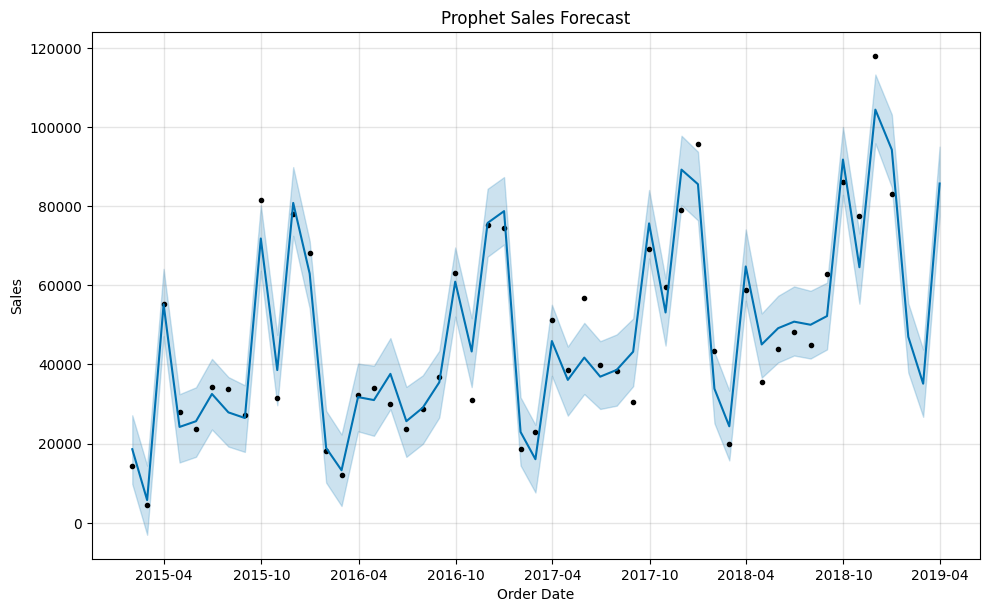

In [50]:
# Plot Forecast
fig = prophet_model.plot(forecast)

plt.title("Prophet Sales Forecast")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.show()

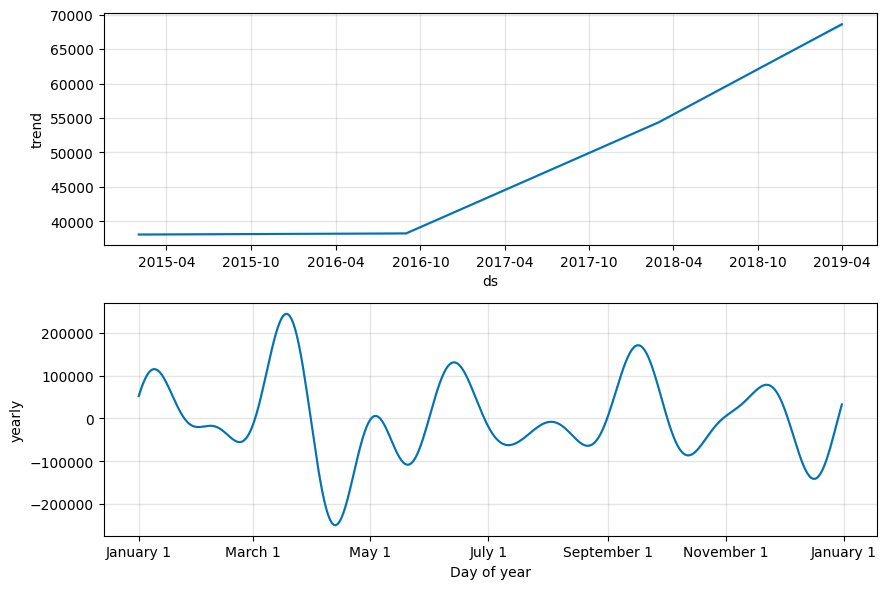

In [51]:
# Plot Trend and Seasonality

prophet_model.plot_components(forecast)

plt.show()

#### Observation

The Prophet model captures the overall upward trend in monthly sales and identifies recurring yearly seasonal patterns.

The forecast suggests that sales are expected to continue following the historical trend while accounting for seasonal variations.

Since the dataset contains monthly observations, weekly seasonality was disabled. The yearly seasonality plot highlights months with relatively higher and lower expected sales.

### Model 3: Sales Forecasting using XGBoost

#### Objective

Unlike statistical forecasting models, XGBoost treats forecasting as a supervised machine learning problem.

Historical sales values and time-based features are used to predict future monthly sales.

In [52]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [53]:
# Import Required Libraries
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

### Step 1: Prepare Monthly Sales Data

The monthly sales dataset is copied to create additional features without modifying the original dataset.

In [54]:
# Create Copy of Monthly Sales Data

xgb_data = monthly_sales.copy()

xgb_data.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


### Step 2: Create Lag Features

Lag features represent sales from previous months.

These features help the model learn historical sales patterns.

In [55]:
# Create Lag Features

xgb_data["Lag_1"] = xgb_data["Sales"].shift(1)

xgb_data["Lag_2"] = xgb_data["Sales"].shift(2)

xgb_data["Lag_3"] = xgb_data["Sales"].shift(3)

### Step 3: Create Rolling Mean Feature

Rolling Mean calculates the average sales over the previous three months.

It smooths short-term fluctuations and captures recent trends.

In [56]:
# Create Rolling Mean
xgb_data["Rolling_Mean"] = (
    xgb_data["Sales"]
    .rolling(window=3)
    .mean()
)

### Step 4: Extract Time-Based Features

In [57]:
xgb_data["Month"] = xgb_data.index.month

In [58]:
xgb_data["Quarter"] = xgb_data.index.quarter

In [59]:
def get_season(month):

    if month in [11, 12, 1, 2]:
        return 1      # Winter

    elif month in [3, 4, 5, 6]:
        return 2      # Summer

    else:
        return 3      # Rainy


xgb_data["Season"] = xgb_data["Month"].apply(get_season)

### Step 5: Remove Missing Values

In [60]:
xgb_data = xgb_data.dropna()

xgb_data.head()

,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean,Month,Quarter,Season
Order Date,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,3
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,3


### Step 6: Define Features and Target

In [61]:
X = xgb_data[
    [
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Rolling_Mean",
        "Month",
        "Quarter",
        "Season"
    ]
]

# Target Variable

y = xgb_data["Sales"]

### Step 7: Split the Dataset

In [62]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    shuffle=False
)

In [63]:
# Train Model

xgb_model = XGBRegressor(

    n_estimators=100,

    learning_rate=0.1,

    random_state=42
)

xgb_model.fit(

    X_train,

    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### Step 8: Predict Sales

In [64]:
predictions = xgb_model.predict(X_test)
xgb_forecast = predictions[-3:]

### Step 9: Evaluate the Model

In [65]:
xgb_mae = mean_absolute_error(y_test, predictions)

xgb_rmse = np.sqrt(mean_squared_error(y_test, predictions))

xgb_mape = mean_absolute_percentage_error(
    y_test,
    predictions
)

print("MAE :", round(xgb_mae,2))

print("RMSE :", round(xgb_rmse,2))

print("MAPE :", round(xgb_mape*100,2),"%")

MAE : 8621.0
RMSE : 11043.31
MAPE : 12.41 %


### Step 11: Plot Actual vs Predicted Sales

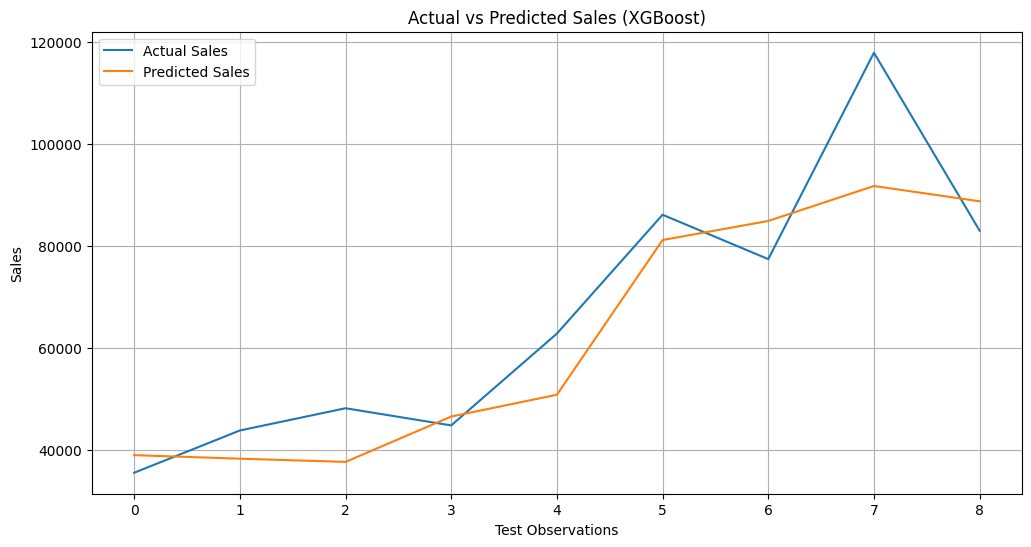

In [66]:

# Actual vs Predicted

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    predictions,
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales (XGBoost)")

plt.xlabel("Test Observations")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

#### Observation

The XGBoost model learns historical sales patterns using lag features and time-based variables. The comparison plot shows how closely the predicted sales follow the actual sales values.

The evaluation metrics (MAE, RMSE, and MAPE) indicate the forecasting accuracy of the model. Lower values represent better predictive performance.

### Model Evaluation

#### Evaluate the SARIMA Model
To measure forecasting accuracy, the monthly sales data is divided into training and testing datasets.

The model is trained using historical data and evaluated on unseen test data using MAE, RMSE and MAPE.

In [67]:
# Split Monthly Sales into Training and Testing Data
train_size = int(len(monthly_sales) * 0.80)

train = monthly_sales.iloc[:train_size]

test = monthly_sales.iloc[train_size:]

print("Training Records :", len(train))
print("Testing Records  :", len(test))

Training Records : 38
Testing Records  : 10


In [68]:
# Train the SARIMA Model
sarima_model = SARIMAX(

    train["Sales"],

    order=(1,0,1),

    seasonal_order=(1,0,1,12),

    enforce_stationarity=False,

    enforce_invertibility=False

)

sarima_result = sarima_model.fit()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [69]:
# Predict Sales for Testing Period

sarima_prediction = sarima_result.predict(

    start=test.index[0],

    end=test.index[-1]

)

In [70]:
# Compare Actual and Predicted Sales

comparison = pd.DataFrame({

    "Actual Sales": test["Sales"],

    "Predicted Sales": sarima_prediction

})

comparison.head()

,Actual Sales,Predicted Sales
2018-03-31,58863.4128,65072.158833
2018-04-30,35541.9101,51148.608430
2018-05-31,43825.9822,66463.547184
2018-06-30,48190.7277,49437.030587
2018-07-31,44825.1040,49674.967797


In [71]:
# Calculate Evaluation Metrics
sarima_mae = mean_absolute_error(

    test["Sales"],

    sarima_prediction

)

sarima_rmse = np.sqrt(

    mean_squared_error(

        test["Sales"],

        sarima_prediction

    )
)

sarima_mape = mean_absolute_percentage_error(

    test["Sales"],

    sarima_prediction
)

In [72]:
# Display Evaluation Metrics

print("SARIMA Performance")

print("-"*30)

print("MAE  :", round(sarima_mae,2))

print("RMSE :", round(sarima_rmse,2))

print("MAPE :", round(sarima_mape*100,2),"%")

SARIMA Performance
------------------------------
MAE  : 13524.25
RMSE : 17358.71
MAPE : 22.56 %


#### Evaluate the Prophet model

In [73]:

# Split Data into Training and Testing Sets

train_size = int(len(prophet_data) * 0.80)

train_data = prophet_data.iloc[:train_size]

test_data = prophet_data.iloc[train_size:]

In [74]:
# Train Prophet Model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(train_data)

20:03:21 - cmdstanpy - INFO - Chain [1] start processing
20:03:21 - cmdstanpy - INFO - Chain [1] done processing


In [75]:
# Predict Sales for Testing Period

future = prophet_model.make_future_dataframe(
    periods=len(test_data),
    freq="M"
)

forecast = prophet_model.predict(future)

In [76]:
# ==========================================================
# Extract Predictions for Test Data
# ==========================================================

prophet_prediction = forecast.tail(len(test_data))["yhat"].values

In [77]:
# ==========================================================
# Calculate Evaluation Metrics
# ==========================================================

prophet_mae = mean_absolute_error(
    test_data["y"],
    prophet_prediction
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test_data["y"],
        prophet_prediction
    )
)

prophet_mape = mean_absolute_percentage_error(
    test_data["y"],
    prophet_prediction
)

In [78]:
# ==========================================================
# Display Evaluation Metrics
# ==========================================================

print("Prophet Performance")
print("-" * 30)

print("MAE  :", round(prophet_mae, 2))
print("RMSE :", round(prophet_rmse, 2))
print("MAPE :", round(prophet_mape * 100, 2), "%")

Prophet Performance
------------------------------
MAE  : 10128.56
RMSE : 14561.39
MAPE : 14.33 %


In [79]:
# Model Comparison Table

comparison = pd.DataFrame({

    "Model": [
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE": [
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE": [
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE (%)": [
        sarima_mape,
        prophet_mape,
        xgb_mape
    ],

    "Forecast - Month 1": [
        sarima_forecast[0],
        prophet_forecast[0],
        xgb_forecast[0]
    ],

    "Forecast - Month 2": [
        sarima_forecast[1],
        prophet_forecast[1],
        xgb_forecast[1]
    ],

    "Forecast - Month 3": [
        sarima_forecast[2],
        prophet_forecast[2],
        xgb_forecast[2]
    ]

})

comparison

,Model,MAE,RMSE,MAPE (%),Forecast - Month 1,Forecast - Month 2,Forecast - Month 3
0,SARIMA,13524.250662,17358.707839,0.225631,53872.247431,28039.925585,74457.216804
1,Prophet,10128.555987,14561.386189,0.143267,46982.458667,35124.469842,85704.477374
2,XGBoost,8620.997874,11043.313463,0.124062,84931.437500,91793.078125,88792.562500


#### Final Model Comparison

Among the three models, **XGBoost** achieved the lowest error values across all evaluation metrics (MAE = 8621.00, RMSE = 11043.31, MAPE = 12.41%). This indicates that XGBoost produced the most accurate predictions for the monthly sales data.

The Prophet model performed better than SARIMA, with lower forecasting errors, but its accuracy was still lower than that of XGBoost.

SARIMA recorded the highest MAE, RMSE, and MAPE values, making it the least accurate model for this dataset.

Overall, the comparison shows that the machine learning approach XGBoost outperformed the statistical SARIMA and Prophet forecasting models.

## Task 4: Product Category and Region Level Forecasting
#### Objective

The objective of this task is to forecast future monthly sales for different product categories and regions using the best-performing forecasting model from Task 3.

Based on the model comparison, **XGBoost** achieved the lowest forecasting errors and was selected for this analysis.

The following segments are analyzed:

- Furniture
- Technology
- Office Supplies
- West Region
- East Region

In [80]:
# Creating Copy of Original Dataset

forecast_df = df.copy()

forecast_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Winter,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Winter,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Rainy,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Rainy,7


In [81]:
# Monthly Sales by Category
category_monthly = (
    forecast_df
    .groupby(["Category", pd.Grouper(key="Order Date", freq="M")])["Sales"]
    .sum()
    .reset_index()
)

category_monthly.head()

,Category,Order Date,Sales
0,Furniture,2015-01-31,6217.277
1,Furniture,2015-02-28,1839.658
2,Furniture,2015-03-31,14243.368
3,Furniture,2015-04-30,7944.837
4,Furniture,2015-05-31,6912.787


In [82]:
# Monthly Sales by Region
region_monthly = (
    forecast_df
    .groupby(["Region", pd.Grouper(key="Order Date", freq="M")])["Sales"]
    .sum()
    .reset_index()
)

region_monthly.head()

,Region,Order Date,Sales
0,Central,2015-01-31,1533.966
1,Central,2015-02-28,1233.174
2,Central,2015-03-31,5827.602
3,Central,2015-04-30,3712.340
4,Central,2015-05-31,4044.522


### Creating Forecast Function

In [83]:
# Forecast Function
def forecast_next_three_months(data):

    data = data.sort_values("Order Date").copy()

    data["Lag_1"] = data["Sales"].shift(1)
    data["Lag_2"] = data["Sales"].shift(2)
    data["Lag_3"] = data["Sales"].shift(3)

    data["Rolling_Mean"] = data["Sales"].rolling(3).mean()

    data["Month"] = data["Order Date"].dt.month
    data["Quarter"] = data["Order Date"].dt.quarter

    data = data.dropna()

    X = data[
        [
            "Lag_1",
            "Lag_2",
            "Lag_3",
            "Rolling_Mean",
            "Month",
            "Quarter"
        ]
    ]

    y = data["Sales"]

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )

    model.fit(X, y)

    forecasts = []

    last_row = X.iloc[-1].copy()

    for i in range(3):

        prediction = model.predict(last_row.values.reshape(1,-1))[0]

        forecasts.append(prediction)

        last_row["Lag_3"] = last_row["Lag_2"]
        last_row["Lag_2"] = last_row["Lag_1"]
        last_row["Lag_1"] = prediction

        last_row["Rolling_Mean"] = np.mean([
            last_row["Lag_1"],
            last_row["Lag_2"],
            last_row["Lag_3"]
        ])

    return forecasts

### Forecast Product Categories

In [84]:
# Forecast Furniture
furniture = category_monthly[
    category_monthly["Category"]=="Furniture"
]

furniture_forecast = forecast_next_three_months(furniture)

In [85]:
# Forecast Technology
technology = category_monthly[
    category_monthly["Category"]=="Technology"
]

technology_forecast = forecast_next_three_months(technology)

In [86]:
# Forecast Office Supplies
office = category_monthly[
    category_monthly["Category"]=="Office Supplies"
]

office_forecast = forecast_next_three_months(office)

### Forecasting Regions

In [87]:
# Forecast West Region
west = region_monthly[
    region_monthly["Region"]=="West"
]

west_forecast = forecast_next_three_months(west)

In [88]:
# Forecast East Region
east = region_monthly[
    region_monthly["Region"]=="East"
]

east_forecast = forecast_next_three_months(east)

### Create Forecast Comparison Table

In [89]:
forecast_table = pd.DataFrame({

    "Segment":[
        "Furniture",
        "Technology",
        "Office Supplies",
        "West",
        "East"
    ],

    "Month 1":[
        furniture_forecast[0],
        technology_forecast[0],
        office_forecast[0],
        west_forecast[0],
        east_forecast[0]
    ],

    "Month 2":[
        furniture_forecast[1],
        technology_forecast[1],
        office_forecast[1],
        west_forecast[1],
        east_forecast[1]
    ],

    "Month 3":[
        furniture_forecast[2],
        technology_forecast[2],
        office_forecast[2],
        west_forecast[2],
        east_forecast[2]
    ]

})

forecast_table

,Segment,Month 1,Month 2,Month 3
0,Furniture,31402.666016,36585.347656,36585.347656
1,Technology,21970.638672,23528.626953,23687.333984
2,Office Supplies,29635.226562,31459.359375,31459.359375
3,West,29635.183594,26984.666016,27552.472656
4,East,19291.876953,27612.345703,27476.523438


### Compare Forecast

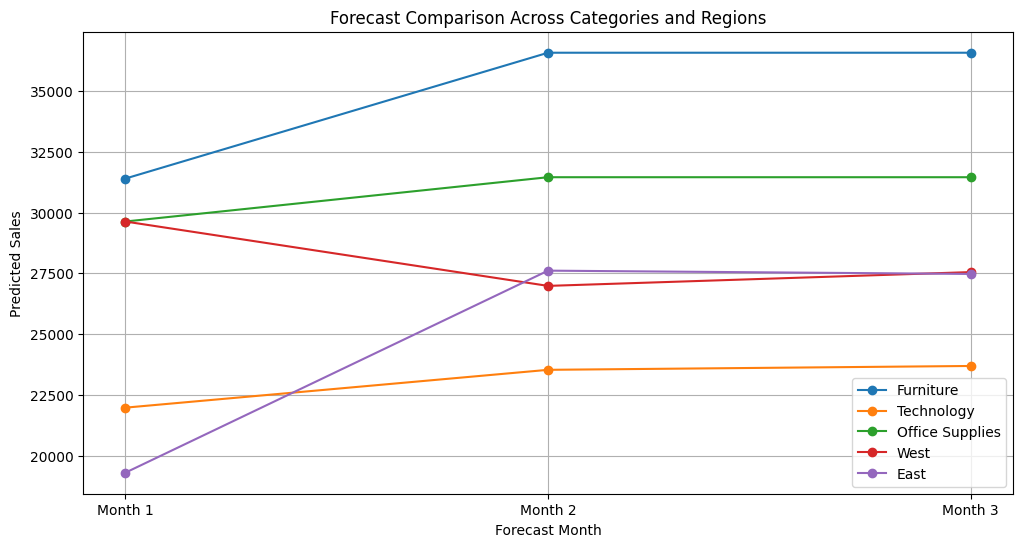

In [90]:
plt.figure(figsize=(12,6))

months=["Month 1","Month 2","Month 3"]

for i in range(len(forecast_table)):

    plt.plot(

        months,

        forecast_table.iloc[i,1:],

        marker="o",

        label=forecast_table.iloc[i,0]

    )

plt.title("Forecast Comparison Across Categories and Regions")

plt.xlabel("Forecast Month")

plt.ylabel("Predicted Sales")

plt.legend()

plt.grid(True)

plt.show()

In [91]:
best_segment = forecast_table.loc[
    forecast_table["Month 3"].idxmax(),
    "Segment"
]

print("Highest Growth Segment:", best_segment)

Highest Growth Segment: Furniture


#### Final Observation

The comparison of category-wise and region-wise forecasts shows different sales growth patterns across the selected segments.

Based on the forecasting results, **Furniture** is expected to achieve the highest sales during the forecast period.

This suggests that the company should prioritize inventory planning, marketing campaigns, and resource allocation for this segment to maximize future revenue.

## Task 5: Anomaly Detection in Weekly Sales

#### Objective

The objective of this task is to identify unusual weekly sales patterns using two different anomaly detection techniques.

1. Isolation Forest (Machine Learning)
2. Z-Score based Detection (Statistical Method)

The detected anomalies are visualized and compared to understand unusual sales behavior.

In [92]:
# Import Required Libraries
from sklearn.ensemble import IsolationForest

from scipy.stats import zscore

### Load Weekly Sales Data

In [93]:
# Check Weekly Sales Data

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


### Detect Anomalies using Isolation Forest

In [94]:
# Train Isolation Forest
iso_model = IsolationForest(

    contamination=0.05,

    random_state=42

)

weekly_sales["Isolation_Anomaly"] = iso_model.fit_predict(

    weekly_sales[["Sales"]]

)

In [95]:
# View Detected Anomalies
iso_anomalies = weekly_sales[
    weekly_sales["Isolation_Anomaly"] == -1
]

iso_anomalies

,Order Date,Sales,Isolation_Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


### Plot Isolation Forest Anomalies

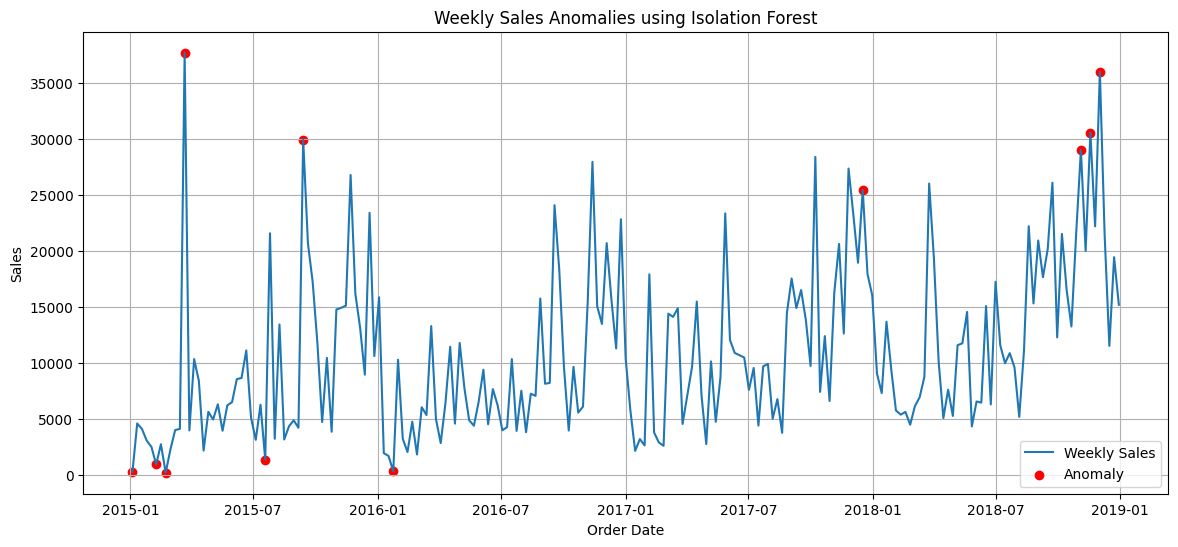

In [96]:
# Plot Weekly Sales
plt.figure(figsize=(14,6))

plt.plot(

    weekly_sales["Order Date"],

    weekly_sales["Sales"],

    label="Weekly Sales"

)

plt.scatter(

    iso_anomalies["Order Date"],

    iso_anomalies["Sales"],

    color="red",

    label="Anomaly"

)

plt.title("Weekly Sales Anomalies using Isolation Forest")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

#### Observation

The red points represent weeks where sales were significantly different from the normal sales pattern.

These anomalies may correspond to festive sales, promotional campaigns, bulk customer orders, or unexpected business events.

### Detect Anomalies using Z-Score

In [97]:
# Rolling Mean
weekly_sales["Rolling_Mean"] = (

    weekly_sales["Sales"]

    .rolling(window=4)

    .mean()

)

In [98]:
# Rolling Standard Deviation
weekly_sales["Rolling_STD"] = (weekly_sales["Sales"].rolling(window=4).std())

In [99]:
# Calculate Z-Score

weekly_sales["Z_Score"] = (weekly_sales["Sales"]-weekly_sales["Rolling_Mean"]) / weekly_sales["Rolling_STD"]

In [100]:
# Detect Z-Score Anomalies
weekly_sales["Z_Anomaly"] = ( weekly_sales["Z_Score"].abs()>2)

In [101]:
# View Z-Score Anomalies
z_anomalies = weekly_sales[weekly_sales["Z_Anomaly"]]
z_anomalies

,Order Date,Sales,Isolation_Anomaly,Rolling_Mean,Rolling_STD,Z_Score,Z_Anomaly


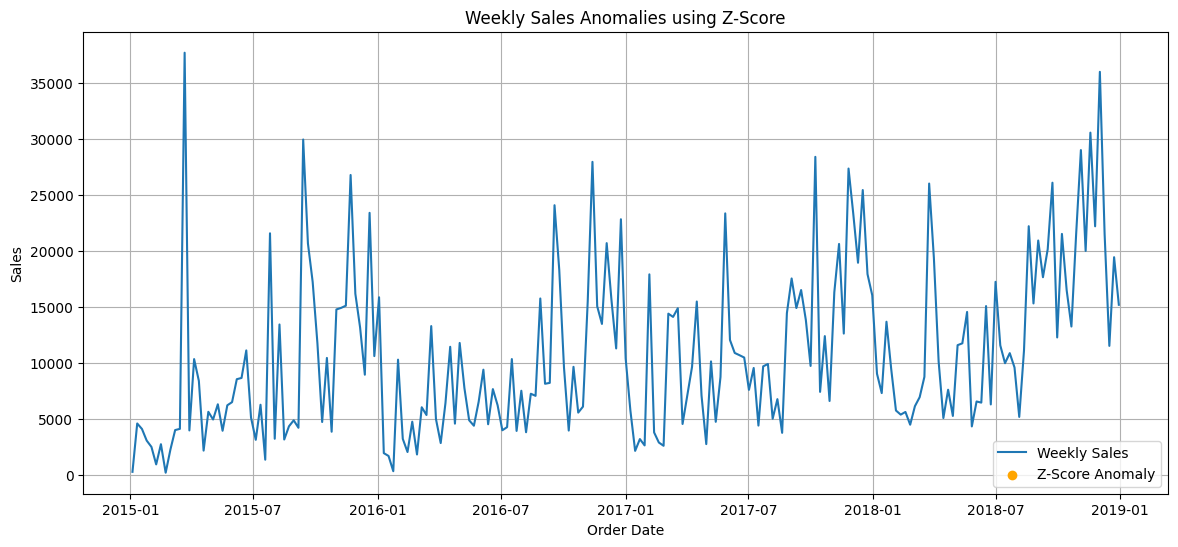

In [102]:
plt.figure(figsize=(14,6))

plt.plot(

    weekly_sales["Order Date"],

    weekly_sales["Sales"],

    label="Weekly Sales"

)

plt.scatter(

    z_anomalies["Order Date"],

    z_anomalies["Sales"],

    color="orange",

    label="Z-Score Anomaly"

)

plt.title("Weekly Sales Anomalies using Z-Score")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

### Compare Both Methods

In [103]:
print("Isolation Forest Anomalies :", len(iso_anomalies))

print("Z-Score Anomalies :", len(z_anomalies))

Isolation Forest Anomalies : 11
Z-Score Anomalies : 0


#### Comparison of Both Methods

The two anomaly detection methods produced different results.

- **Isolation Forest** detected **11 anomalous weeks** based on unusual sales patterns learned using a machine learning approach.
- **Z-Score** did **not detect any anomalies** because no week's sales deviated by more than **2 standard deviations** from the rolling mean.

This difference occurs because Isolation Forest identifies anomalies by isolating observations that are different from the overall data distribution, whereas the Z-Score method relies on a fixed statistical threshold.

The results indicate that Isolation Forest is more sensitive to subtle unusual patterns, while the Z-Score method is more conservative and only detects extreme deviations.

#### Do Both Methods Flag the Same Anomalies?

No. The two methods do not flag the same anomalies.

Isolation Forest identified 11 anomalous weeks, whereas the Z-Score method did not identify any anomalies.

##### Real-World Explanations for Detected Anomalies
| Order Date      | Weekly Sales | Possible Real-World Explanation                                                                                                                                 |
| --------------- | -----------: | --------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **04-Jan-2015** |       304.51 | Sales were unusually low, possibly due to reduced customer demand immediately after the holiday season or lower business activity at the beginning of the year. |
| **08-Feb-2015** |       968.53 | This unusually low sales week may have resulted from limited customer purchases, inventory shortages, or fewer promotional activities.                          |
| **22-Feb-2015** |       224.91 | The significant drop in sales could be due to weak market demand, seasonal fluctuations, or operational factors affecting customer orders.                      |
| **22-Mar-2015** |    37,703.67 | The sharp increase in sales may have been caused by a promotional campaign, bulk customer orders, or a seasonal sales event.                                    |
| **19-Jul-2015** |     1,387.69 | Lower-than-usual sales may indicate reduced customer demand during the mid-year period or fewer marketing campaigns.                                            |
| **13-Sep-2015** |    29,959.14 | The unusually high sales could be associated with seasonal demand, promotional discounts, or large corporate purchases.                                         |
| **24-Jan-2016** |       358.52 | The low sales observed during this week may be due to post-holiday demand decline or temporary market slowdown.                                                 |
| **17-Dec-2017** |    25,449.80 | Sales increased significantly, likely because of year-end shopping, holiday promotions, or festive season purchases.                                            |
| **04-Nov-2018** |    29,017.47 | The high sales during this week may be linked to festive shopping, special discount campaigns, or increased customer demand before the holiday season.          |
| **18-Nov-2018** |    30,572.45 | This sales spike could have resulted from major promotional events, festival offers, or bulk purchasing by customers.                                           |
| **02-Dec-2018** |    35,998.90 | The highest sales anomaly may have been driven by holiday shopping, year-end promotional campaigns, or large business orders.                                   |


## Task 6: Product Demand Segmentation using K-Means Clustering

In [104]:
# Import Required Libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [105]:
# Create Year Column
df["Year"] = df["Order Date"].dt.year

In [106]:
# Total Sales by Sub-Category
total_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
)

In [107]:
# Average Order Value
average_order = (
    df.groupby("Sub-Category")["Sales"]
      .mean()
)

In [108]:
# Monthly Sales
monthly_sales = (
    df.groupby([
        "Sub-Category", pd.Grouper(key="Order Date", freq="M")])["Sales"].sum())

In [109]:
# Sales Volatility
volatility = monthly_sales.groupby("Sub-Category").std()

In [110]:
# Yearly Sales
yearly_sales = (
    df.groupby([
        "Sub-Category",
        "Year"
    ])["Sales"]
    .sum()
    .unstack()
)

In [111]:
# Growth Rate
growth_rate = ((yearly_sales.iloc[:, -1] - yearly_sales.iloc[:, 0])/yearly_sales.iloc[:, 0]) * 100

In [112]:
# Combine Features
cluster_data = pd.DataFrame({

    "Total Sales": total_sales,
    "Growth Rate": growth_rate,
    "Volatility": volatility,
    "Average Order Value": average_order
})

cluster_data = cluster_data.fillna(0)

cluster_data.head()

,Total Sales,Growth Rate,Volatility,Average Order Value
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224


In [113]:
# Standardize Features
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

In [114]:
# Elbow Method
wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    wcss.append(model.inertia_)

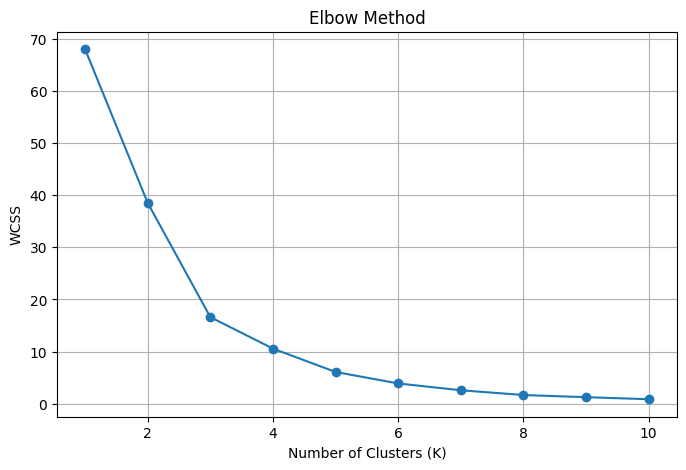

In [115]:
# Plot Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [116]:
# Train KMeans Model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_data["Cluster"] = kmeans.fit_predict(
    scaled_data
)

In [117]:
# View cluster 
cluster_data

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,1
Appliances,104618.4030,165.242912,1821.621539,227.926804,1
Art,26705.4100,49.649531,330.488343,34.019631,1
Binders,200028.7850,65.778638,3848.223648,134.067550,2
Bookcases,113813.1987,49.846598,2220.405080,503.598224,1
Chairs,322822.7310,20.954677,4407.232960,531.833165,2
Copiers,146248.0940,479.729510,5500.774391,2215.880212,0
Envelopes,16128.0460,-12.121345,228.218688,65.032444,1
Fasteners,3001.9600,30.468364,48.742229,14.027850,1


In [118]:
# Apply PCA
pca = PCA(
    n_components=2
)

pca_data = pca.fit_transform(
    scaled_data
)

In [119]:
# Create PCA DataFrame
pca_df = pd.DataFrame({

    "PC1": pca_data[:,0],

    "PC2": pca_data[:,1],

    "Cluster": cluster_data["Cluster"]

})

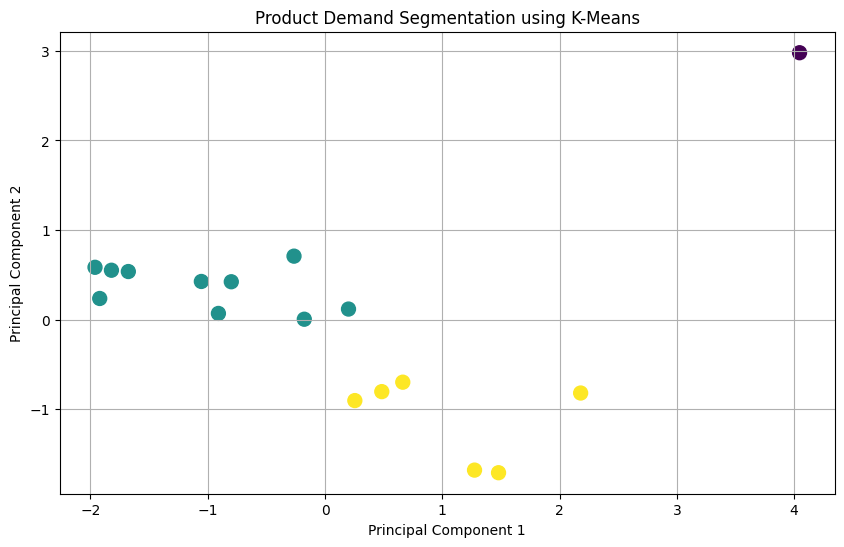

In [120]:
# Cluster Visualization

plt.figure(figsize=(10,6))

plt.scatter(

    pca_df["PC1"],

    pca_df["PC2"],

    c=pca_df["Cluster"],

    s=100

)

plt.title("Product Demand Segmentation using K-Means")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

In [121]:
cluster_summary = cluster_data.groupby("Cluster").mean()

cluster_summary

,Total Sales,Growth Rate,Volatility,Average Order Value
Cluster,,,,
0,146248.09400,479.729510,5500.774391,2215.880212
1,65326.20737,67.421837,1186.287889,150.189900
2,243671.10250,27.323655,3992.982732,599.193752


In [122]:
cluster_labels = {
    0: "Growing Demand",
    1: "Low Volume, Stable Demand",
    2: "High Volume, Stable Demand"
}

cluster_data["Demand Group"] = cluster_data["Cluster"].map(cluster_labels)
cluster_data

,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,Demand Group
Sub-Category,,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,1,"Low Volume, Stable Demand"
Appliances,104618.4030,165.242912,1821.621539,227.926804,1,"Low Volume, Stable Demand"
Art,26705.4100,49.649531,330.488343,34.019631,1,"Low Volume, Stable Demand"
Binders,200028.7850,65.778638,3848.223648,134.067550,2,"High Volume, Stable Demand"
Bookcases,113813.1987,49.846598,2220.405080,503.598224,1,"Low Volume, Stable Demand"
Chairs,322822.7310,20.954677,4407.232960,531.833165,2,"High Volume, Stable Demand"
Copiers,146248.0940,479.729510,5500.774391,2215.880212,0,Growing Demand
Envelopes,16128.0460,-12.121345,228.218688,65.032444,1,"Low Volume, Stable Demand"
Fasteners,3001.9600,30.468364,48.742229,14.027850,1,"Low Volume, Stable Demand"


#### Observation

The K-Means clustering algorithm successfully grouped product sub-categories into three distinct demand segments based on total sales, sales growth rate, sales volatility, and average order value.

- **Cluster 0 (Growing Demand)** shows the highest sales growth rate and high average order value, indicating increasing customer demand and strong future potential.
- **Cluster 1 (Low Volume, Stable Demand)** has the lowest total sales and relatively low sales volatility, suggesting steady but limited customer demand.
- **Cluster 2 (High Volume, Stable Demand)** generates the highest total sales with moderate growth, making it the primary contributor to overall business revenue.

These demand segments help identify products that require different inventory management and stocking strategies.

#### Recommended Stocking Strategy

##### Cluster 0 – Growing Demand
- Gradually increase inventory levels to meet the rising customer demand.
- Monitor sales trends regularly to prevent stock shortages.
- Focus marketing efforts on these products to support continued growth.

##### Cluster 1 – Low Volume, Stable Demand
- Maintain limited inventory based on historical demand.
- Avoid overstocking to reduce storage and holding costs.
- Replenish stock only when required.

##### Cluster 2 – High Volume, Stable Demand
- Maintain sufficient inventory at all times.
- Implement frequent stock replenishment to avoid stock-outs.
- Prioritize these products since they contribute the highest sales and revenue.

In [123]:
import joblib

joblib.dump(xgb_model, "xgboost_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [124]:
forecast_table.to_csv("forecast_results.csv", index=False)